# Veri Seti İndirme ve İnceleme

In [1]:
# Kütüphanelerin Yüklenmesi
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from utils import log_experiment

# Grafik Ayarları
sns.set_style("whitegrid")
%matplotlib inline

# --- Veri Setini Otomatik İndirme ve Yükleme ---
print("Veri seti indiriliyor...")
# KaggleHub veriyi ~/.cache/kagglehub/... altına indirir
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
print("Veri seti yolu:", path)

# İndirilen klasördeki csv dosyasını bul (genelde diabetes.csv)
csv_file = os.path.join(path, "diabetes.csv")

try:
    df = pd.read_csv(csv_file)
    print("\n✅ Veri seti başarıyla yüklendi!")
    print(f"Veri Seti Boyutu: {df.shape}")
except FileNotFoundError:
    print(f"❌ HATA: '{csv_file}' bulunamadı. Lütfen indirilen klasörü kontrol edin.")

# İlk 5 satırı göster
display(df.head())

# Temel Bilgiler
print("\nVeri Seti Bilgileri:")
print(df.info())

/home/husam/Desktop/YTU-YL/Veri Madenciliği/code/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Veri seti indiriliyor...
Veri seti yolu: /home/husam/.cache/kagglehub/datasets/uciml/pima-indians-diabetes-database/versions/1

✅ Veri seti başarıyla yüklendi!
Veri Seti Boyutu: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Veri Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


# EDA

İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


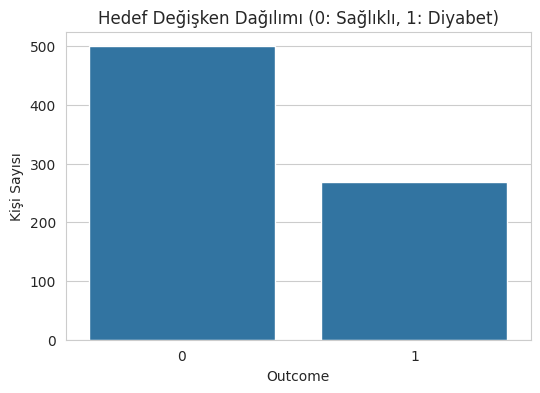

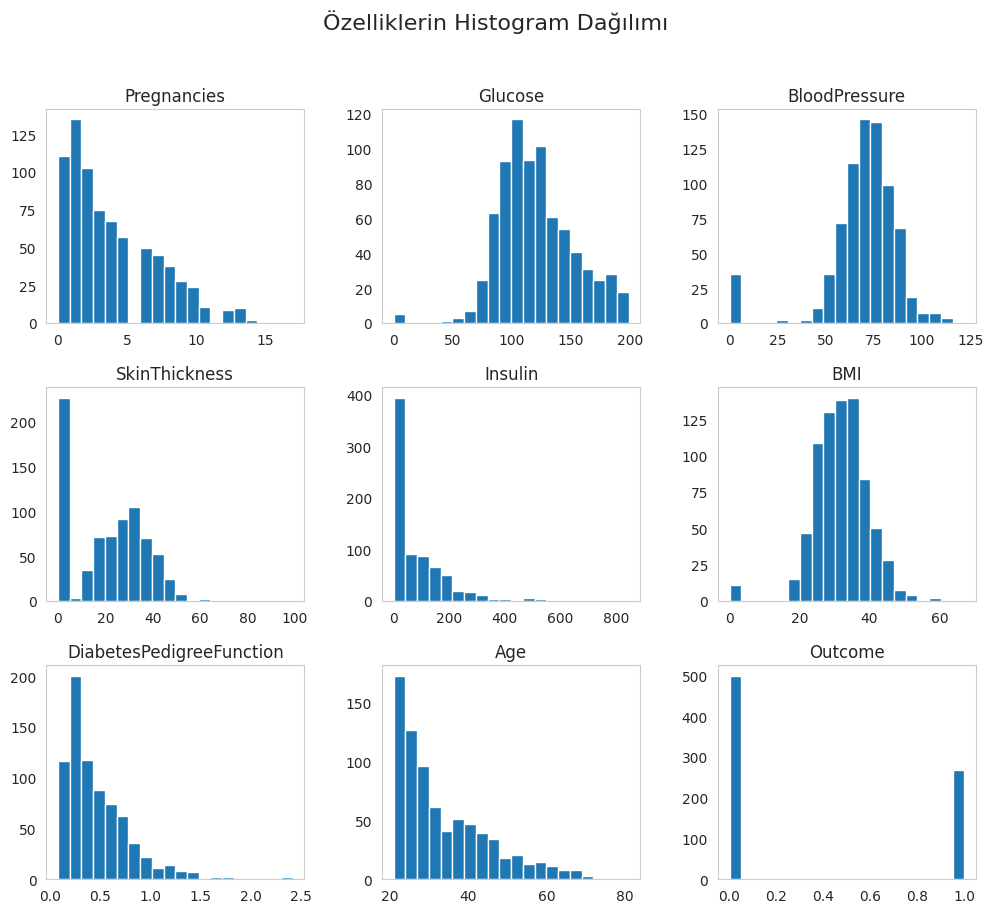

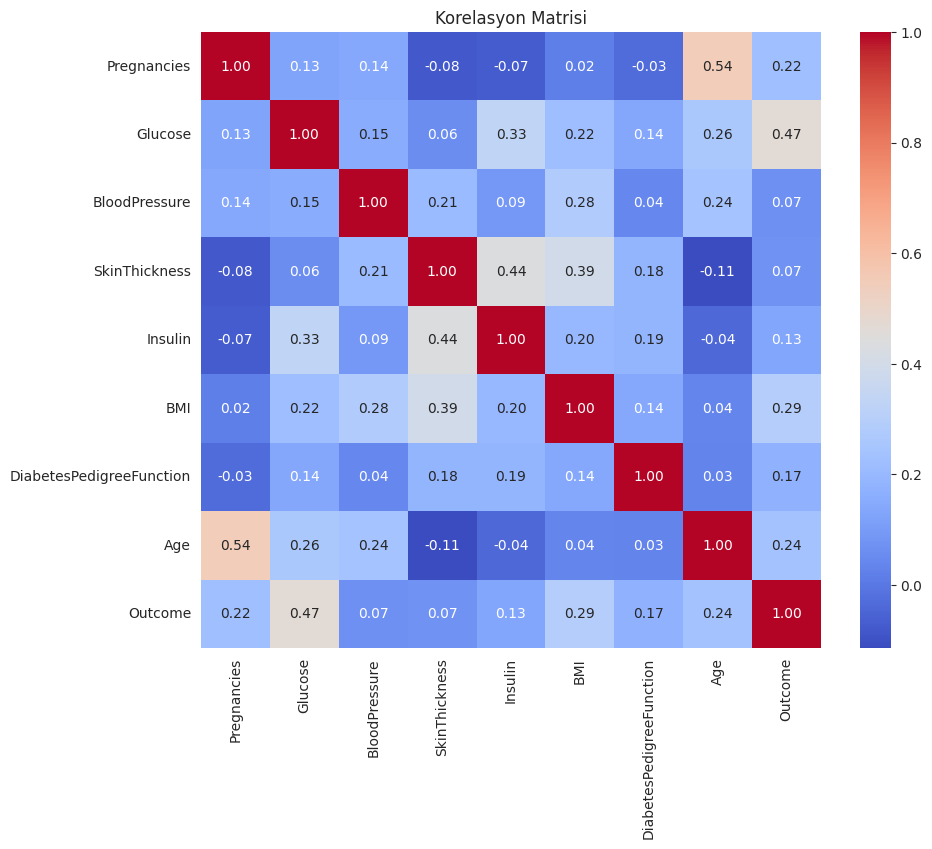

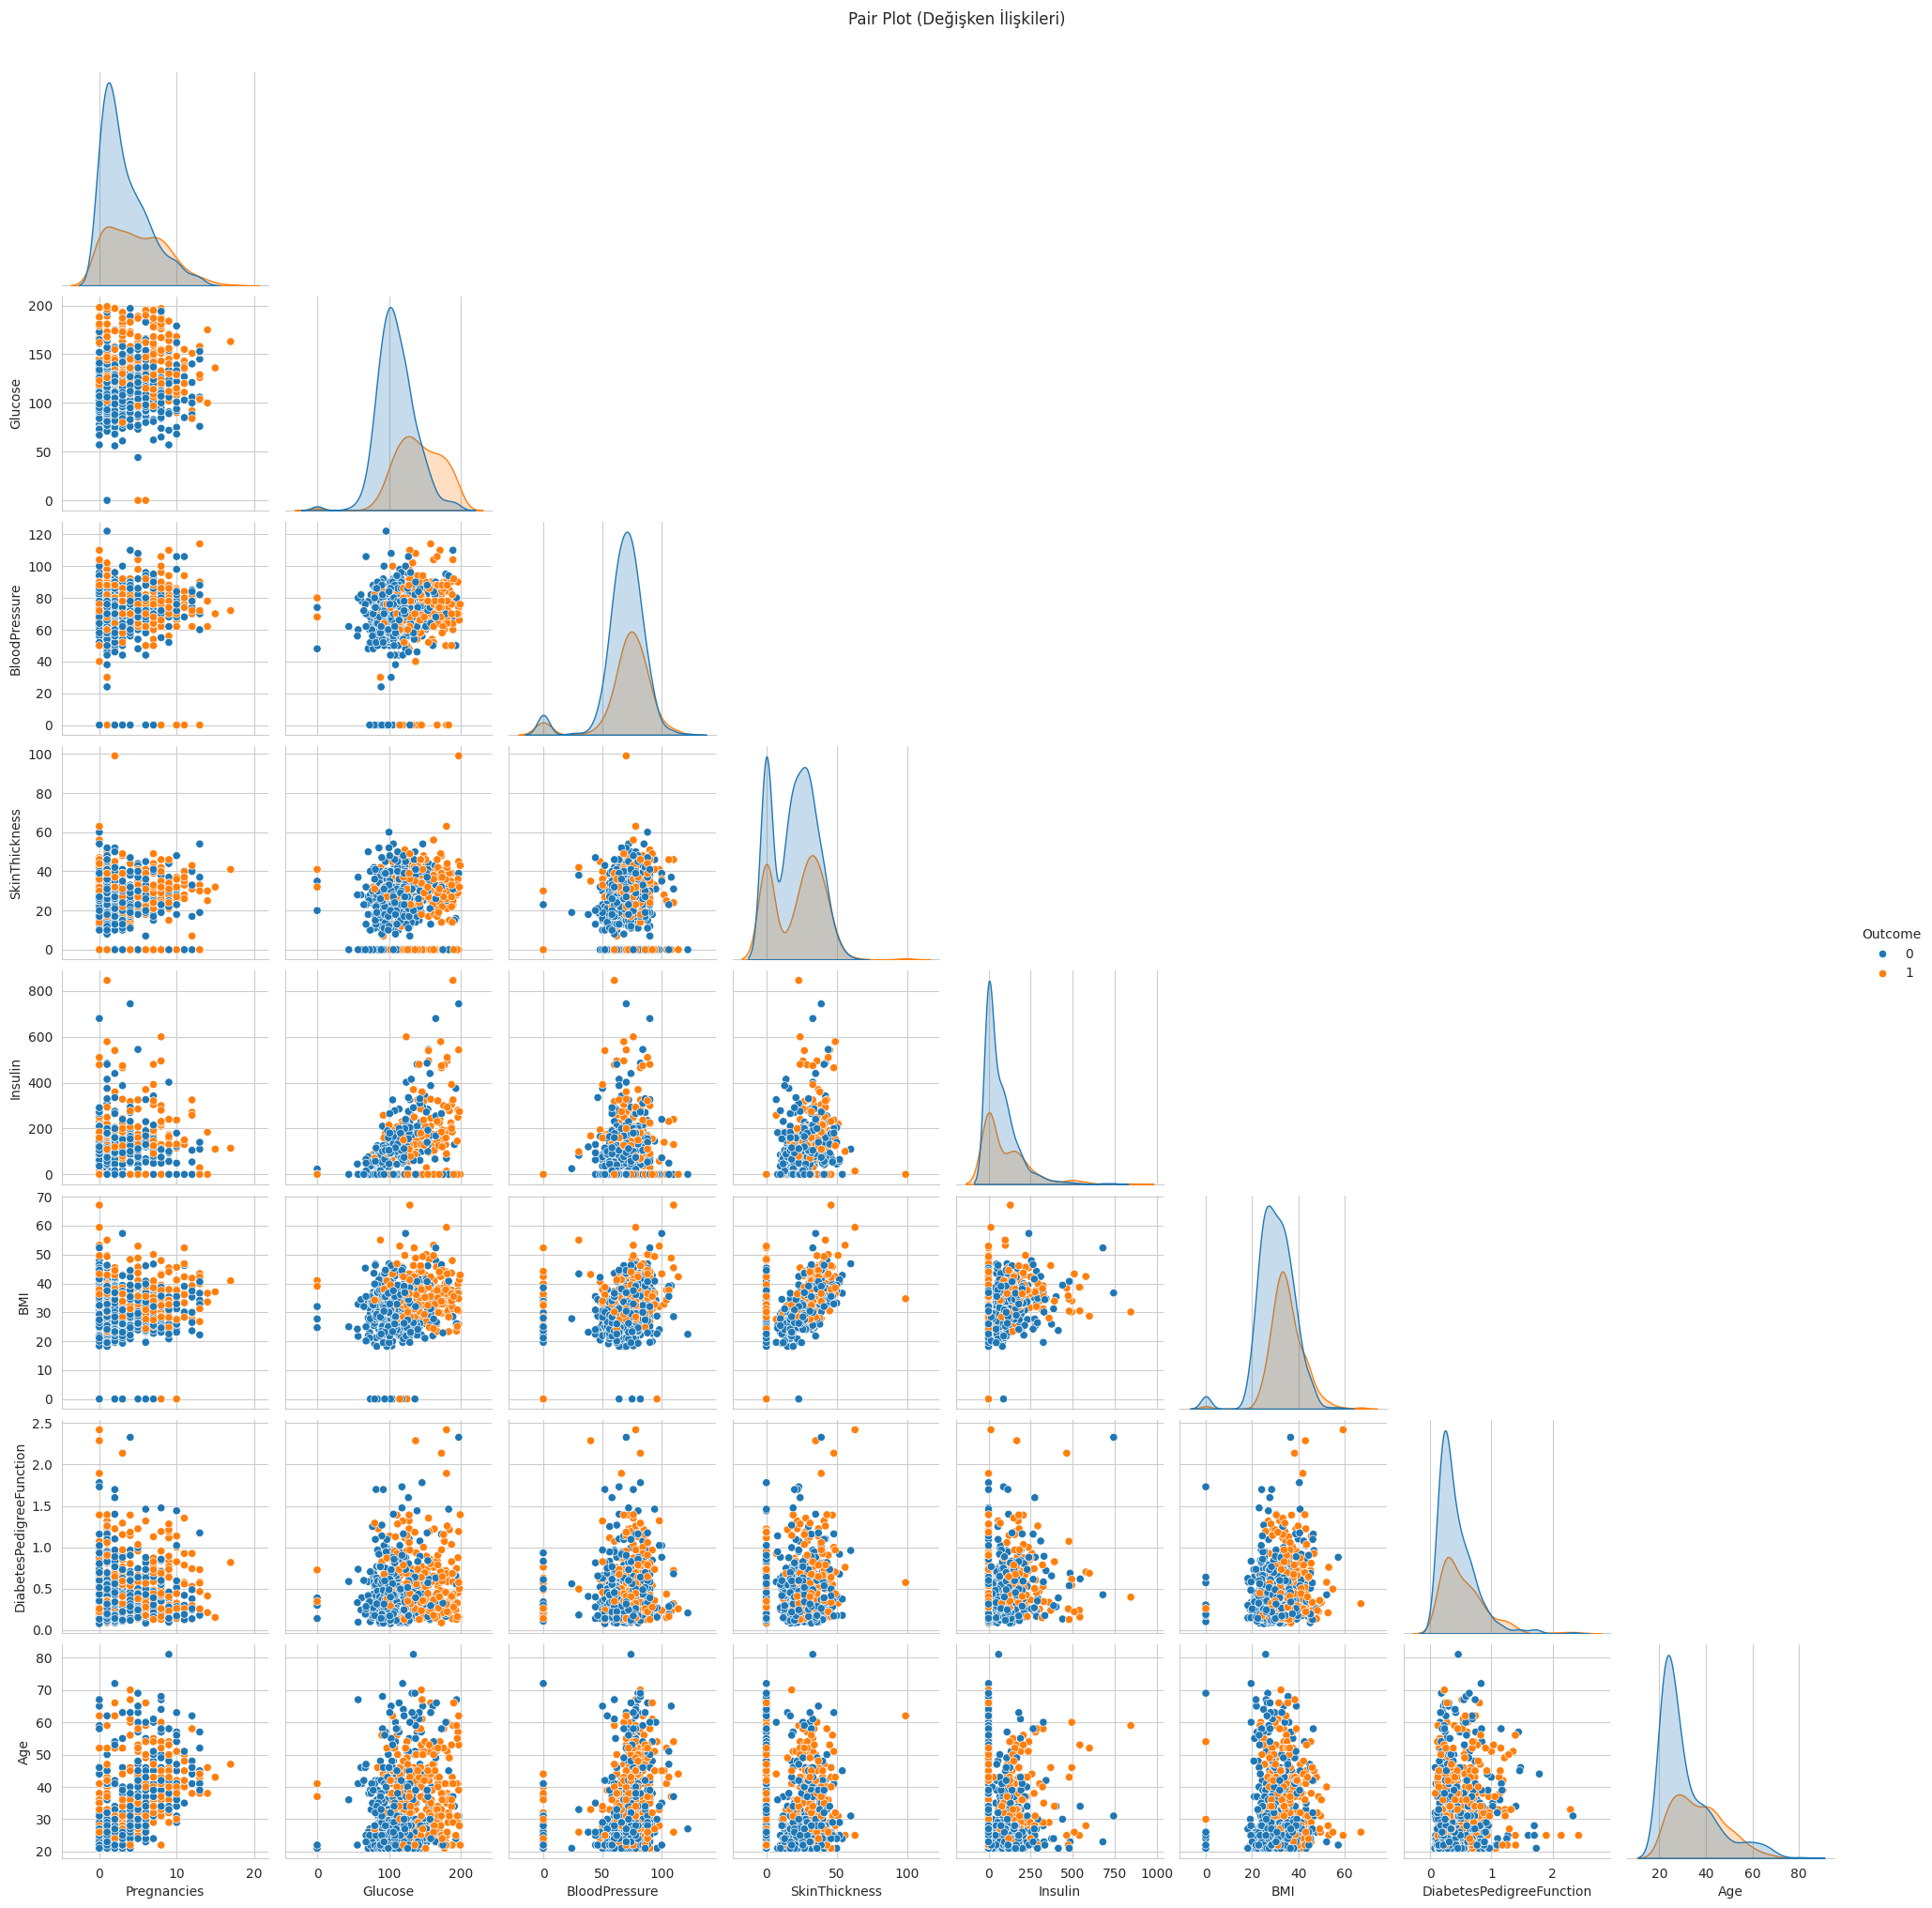

In [2]:
# --- 1.1 Veri Keşfi ve Görselleştirme (EDA) ---

# İstatistiksel Özet
print("İstatistiksel Özet:")
display(df.describe().T)

# Hedef Değişken Dağılımı (Outcome)
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title("Hedef Değişken Dağılımı (0: Sağlıklı, 1: Diyabet)")
plt.xlabel("Outcome")
plt.ylabel("Kişi Sayısı")
plt.show()

# Histogramlar (Her özellik için dağılım)
# Makalede Fig 4'e karşılık gelir
df.hist(figsize=(12, 10), bins=20, grid=False)
plt.suptitle("Özelliklerin Histogram Dağılımı", fontsize=16)
plt.show()

# Korelasyon Matrisi (Opsiyonel ama faydalı)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelasyon Matrisi")
plt.show()

# (İsteğe bağlı) Pair Plot - Değişkenler arası ilişki
# Biraz uzun sürebilir, tüm değişkenleri birbirine karşı çizer
sns.pairplot(df, hue='Outcome', diag_kind='kde', corner=True)
plt.suptitle("Pair Plot (Değişken İlişkileri)", y=1.02)
plt.show()

# Ön işleme

Doldurma öncesi eksik değer sayıları:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Split tamamlandı. Eğitim Seti: (614, 8), Test Seti: (154, 8)

✅ Pipeline uygulandı: Önce StandardScaler, sonra KNNImputer
İşlenmiş Eğitim Seti: (614, 8), İşlenmiş Test Seti: (154, 8)



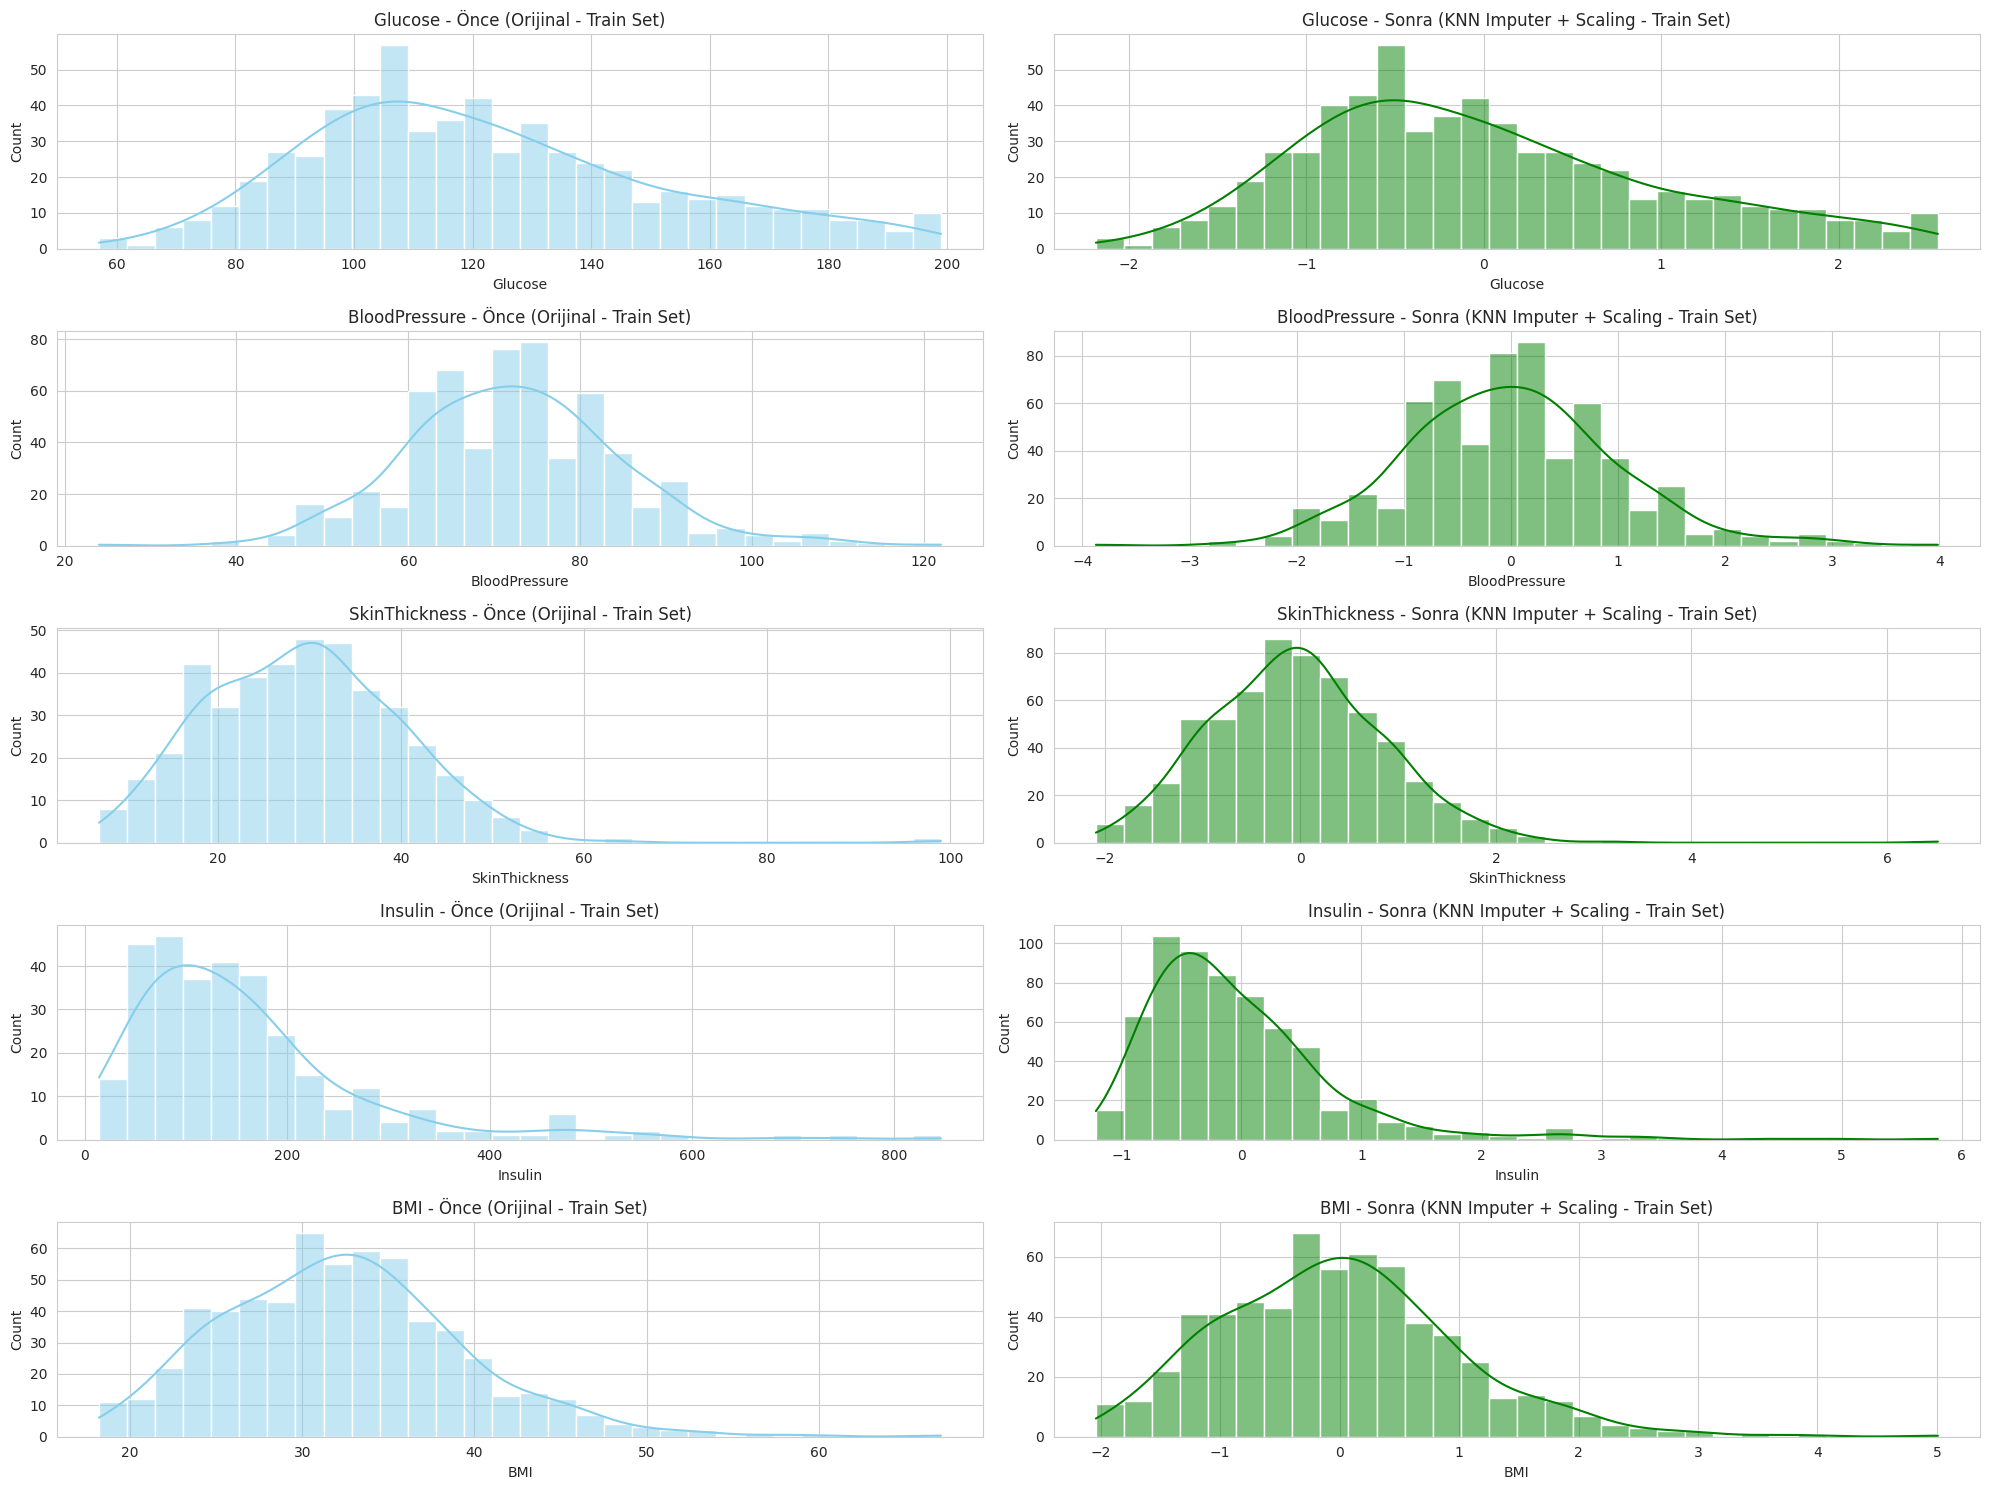

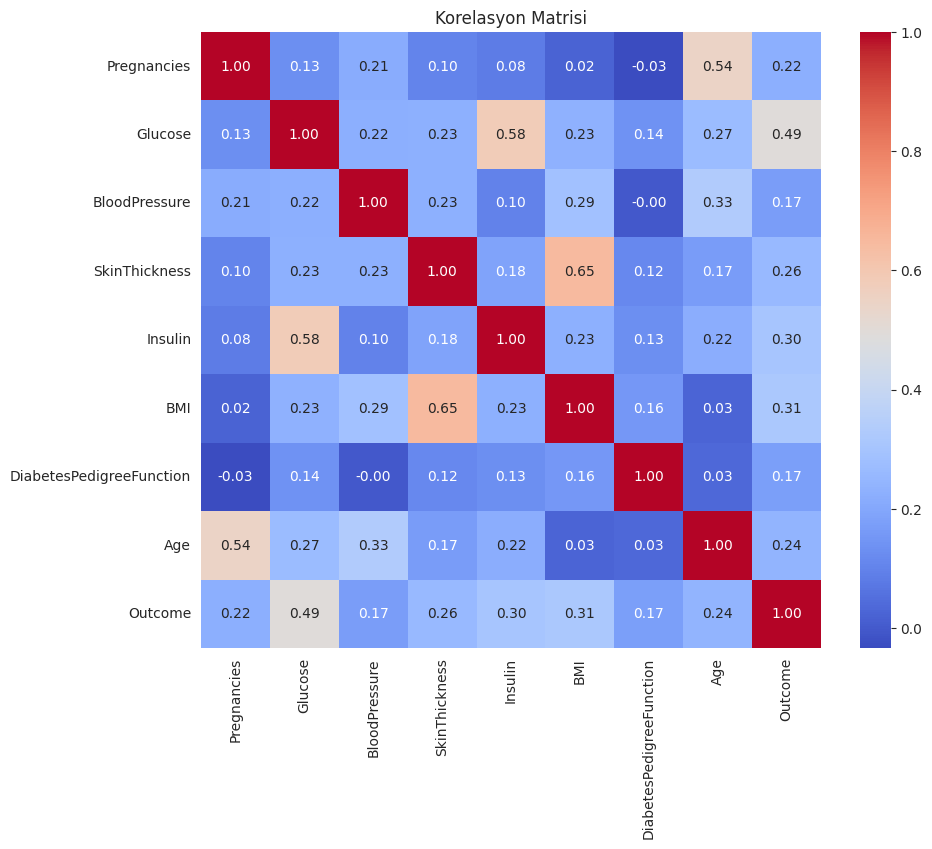

✅ Gelişmiş ön işleme tamamlandı: Önce scaling, sonra KNN Imputer ile dolduruldu.


In [3]:
# --- 3. Veri Ön İşleme (Preprocessing) - GELİŞMİŞ YÖNTEM (KNN Imputer) ---
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline

# 0. Kopya oluştur (Görselleştirme için)
df_original = df.copy()

# 1. Eksik Veri Yönetimi (0 -> NaN)
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Orijinal df üzerinde 0'ları NaN yap (Görselleştirme için)
df_original[zero_features] = df_original[zero_features].replace(0, np.nan)

# İşlenecek df üzerinde de 0'ları NaN yap
df[zero_features] = df[zero_features].replace(0, np.nan)

print(f"Doldurma öncesi eksik değer sayıları:\n{df.isnull().sum()}\n")

# 2. Veri Bölme (Train/Test Split) - ÖNCE SPLIT! (Data Leakage'ı önlemek için)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Seed
SEED = 506

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

print(f"Split tamamlandı. Eğitim Seti: {X_train.shape}, Test Seti: {X_test.shape}\n")

# 3. Pipeline Kur: ÖNCE SCALE, SONRA KNN IMPUTER
# KNNImputer mesafe tabanlı olduğu için önce scaling yapılmalı!
# Bu pipeline, fit edilirken sadece X_train'i görür (data leakage yok)
pipeline = Pipeline([
    ('scaler', StandardScaler()),       # Önce scale et
    ('imputer', KNNImputer(n_neighbors=5)) # Sonra KNN ile doldur
])

# 4. Fit & Transform
# Train setine göre öğren ve uygula
X_train_processed = pipeline.fit_transform(X_train)

# Test setine sadece uygula (Train'den öğrendiği istatistiklerle)
X_test_processed = pipeline.transform(X_test)

# Processed veriyi DataFrame'e geri çevirelim
X_train_df = pd.DataFrame(X_train_processed, columns=X.columns)
X_test_df = pd.DataFrame(X_test_processed, columns=X.columns)

print("✅ Pipeline uygulandı: Önce StandardScaler, sonra KNNImputer")
print(f"İşlenmiş Eğitim Seti: {X_train_df.shape}, İşlenmiş Test Seti: {X_test_df.shape}\n")

# --- GÖRSELLEŞTİRME: Önce vs Sonra Yan Yana (Train setinden örnek) ---
# Görselleştirme için train setindeki doldurulmuş veriyi kullanıyoruz
plt.figure(figsize=(20, 15))
plot_idx = 1

for col in zero_features:
    # 1. Grafik: Doldurma Öncesi (Orijinal - Train setinden)
    plt.subplot(5, 2, plot_idx)
    train_original = X_train[col].dropna()
    if len(train_original) > 0:
        sns.histplot(train_original, kde=True, color='skyblue', bins=30)
    plt.title(f"{col} - Önce (Orijinal - Train Set)")
    plot_idx += 1
    
    # 2. Grafik: Doldurma Sonrası (KNN - Train setinden)
    plt.subplot(5, 2, plot_idx)
    sns.histplot(X_train_df[col], kde=True, color='green', bins=30)
    plt.title(f"{col} - Sonra (KNN Imputer + Scaling - Train Set)")
    plot_idx += 1

plt.tight_layout()
plt.show()

# Korelasyon Matrisi (Opsiyonel ama faydalı)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelasyon Matrisi")
plt.show()

print("✅ Gelişmiş ön işleme tamamlandı: Önce scaling, sonra KNN Imputer ile dolduruldu.")

📊 İŞLENMİŞ EĞİTİM SETİ İNCELEMESİ

1. İstatistiksel Özet (Train Seti):


,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,-5.496870e-17,1.000815,-1.144320,-0.848233,-0.256061,0.632197,3.296971
Glucose,614.0,-1.961711e-03,0.999474,-2.186098,-0.748972,-0.180805,0.621312,2.559762
BloodPressure,614.0,-3.417885e-03,0.984751,-3.874635,-0.665477,-0.023645,0.618187,3.987803
SkinThickness,614.0,-3.197227e-02,0.894690,-2.091299,-0.631028,-0.050663,0.529701,6.520560
Insulin,614.0,-3.822347e-02,0.811658,-1.212967,-0.562040,-0.234891,0.277335,5.802202
BMI,614.0,-2.183819e-03,0.995200,-2.039453,-0.713595,-0.043461,0.569028,5.007770
DiabetesPedigreeFunction,614.0,-1.157236e-16,1.000815,-1.142173,-0.674341,-0.305924,0.424332,5.705713
Age,614.0,-2.922020e-16,1.000815,-1.046094,-0.791952,-0.368382,0.648187,4.036748
Outcome,614.0,3.566775e-01,0.479409,0.000000,0.000000,0.000000,1.000000,1.000000


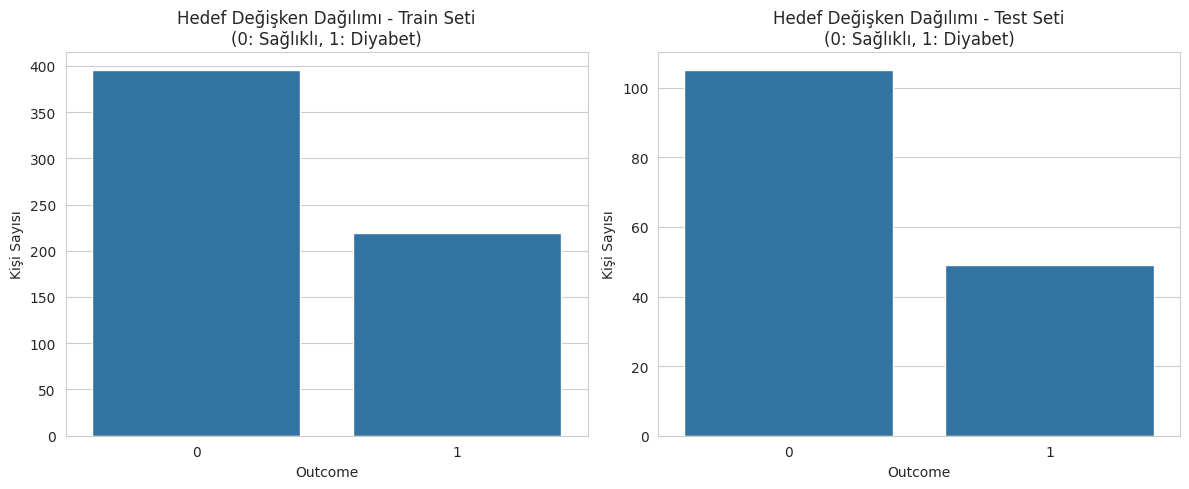


2. Özelliklerin Histogram Dağılımı (Train Seti):


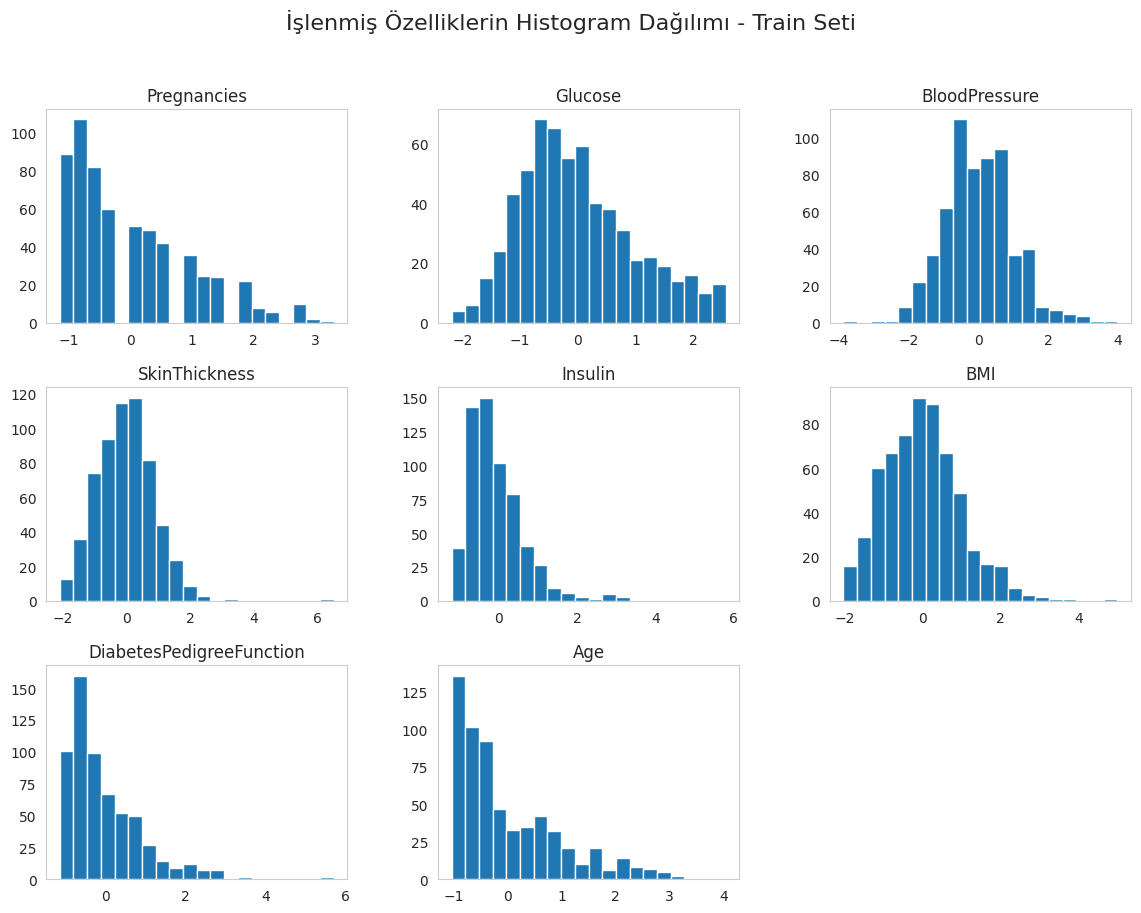


3. Özelliklerin Histogram Dağılımı (Test Seti):


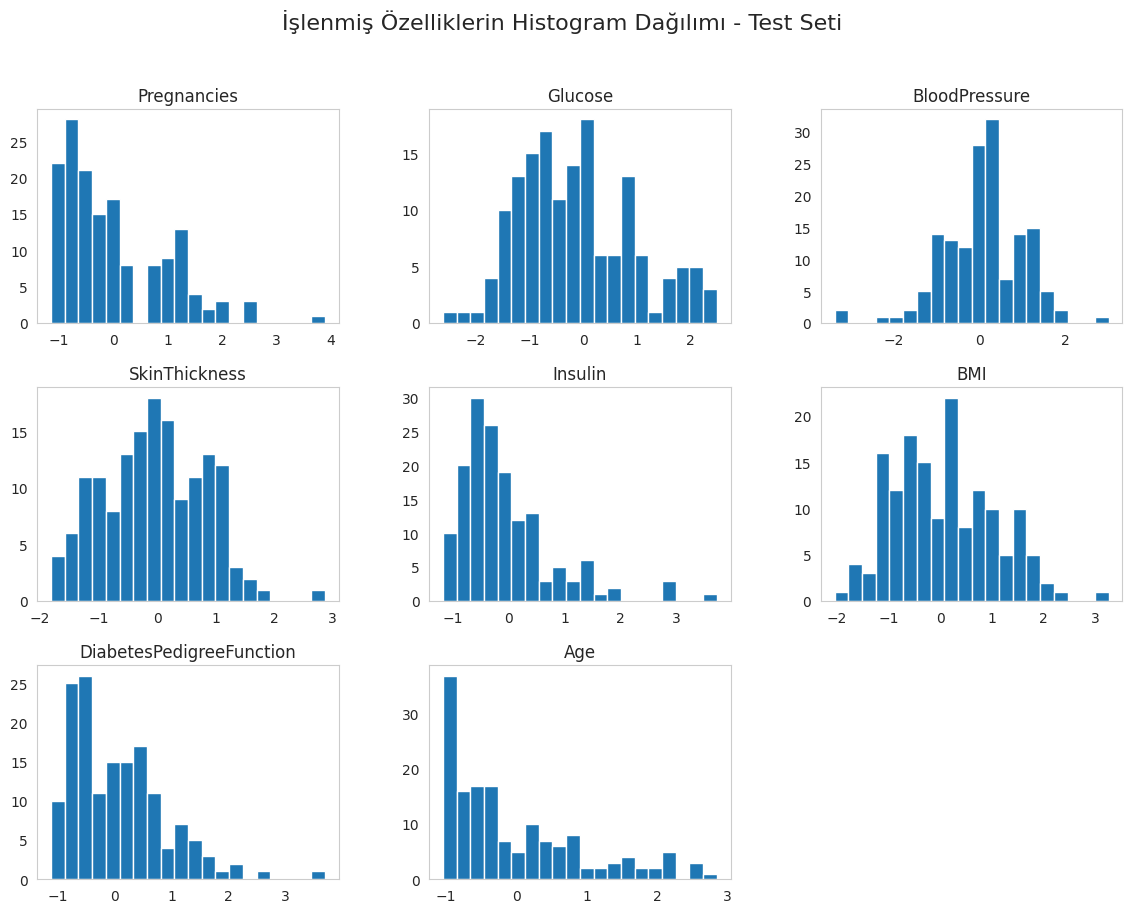


4. Korelasyon Matrisi (Train Seti):


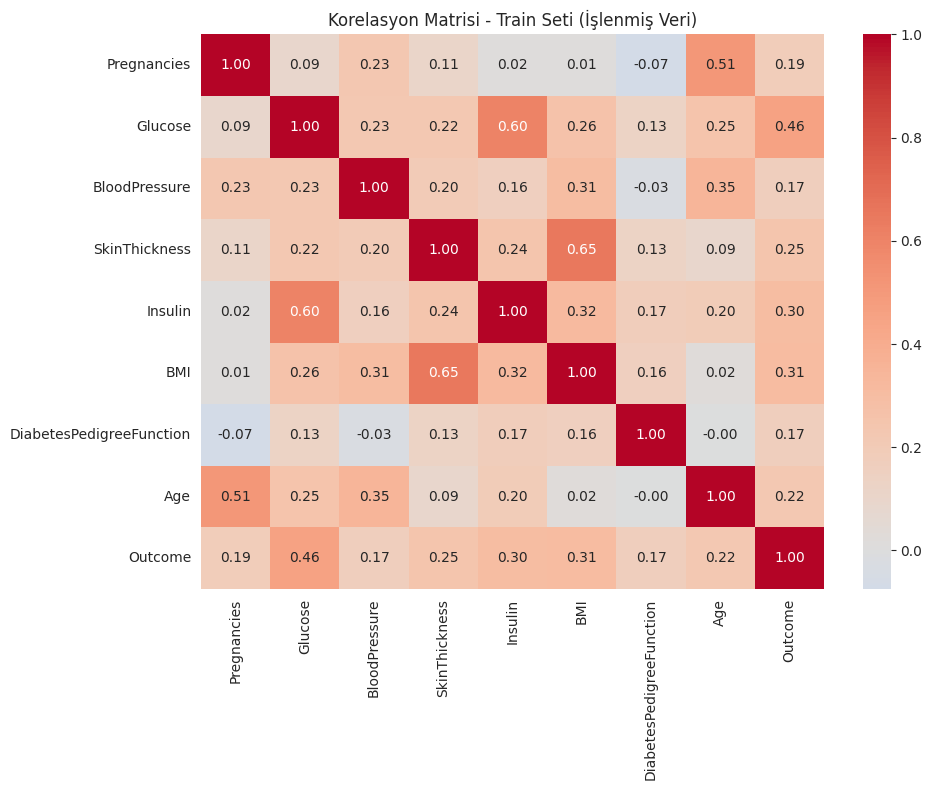


5. Korelasyon Matrisi (Test Seti):


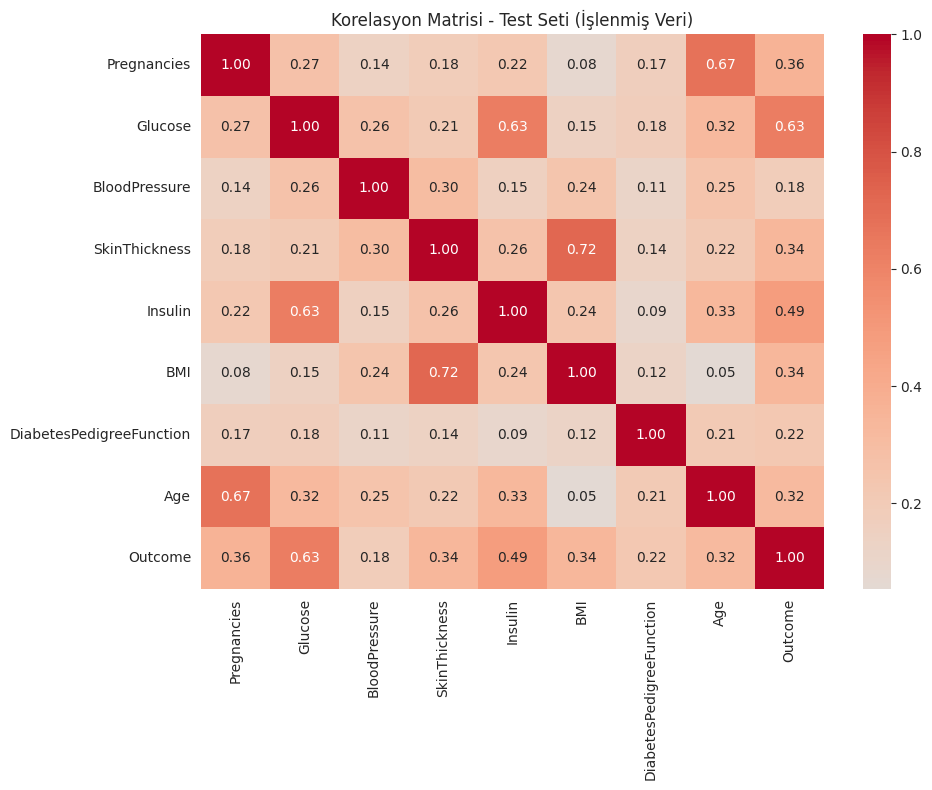


6. Pair Plot - Değişken İlişkileri (Train Seti):


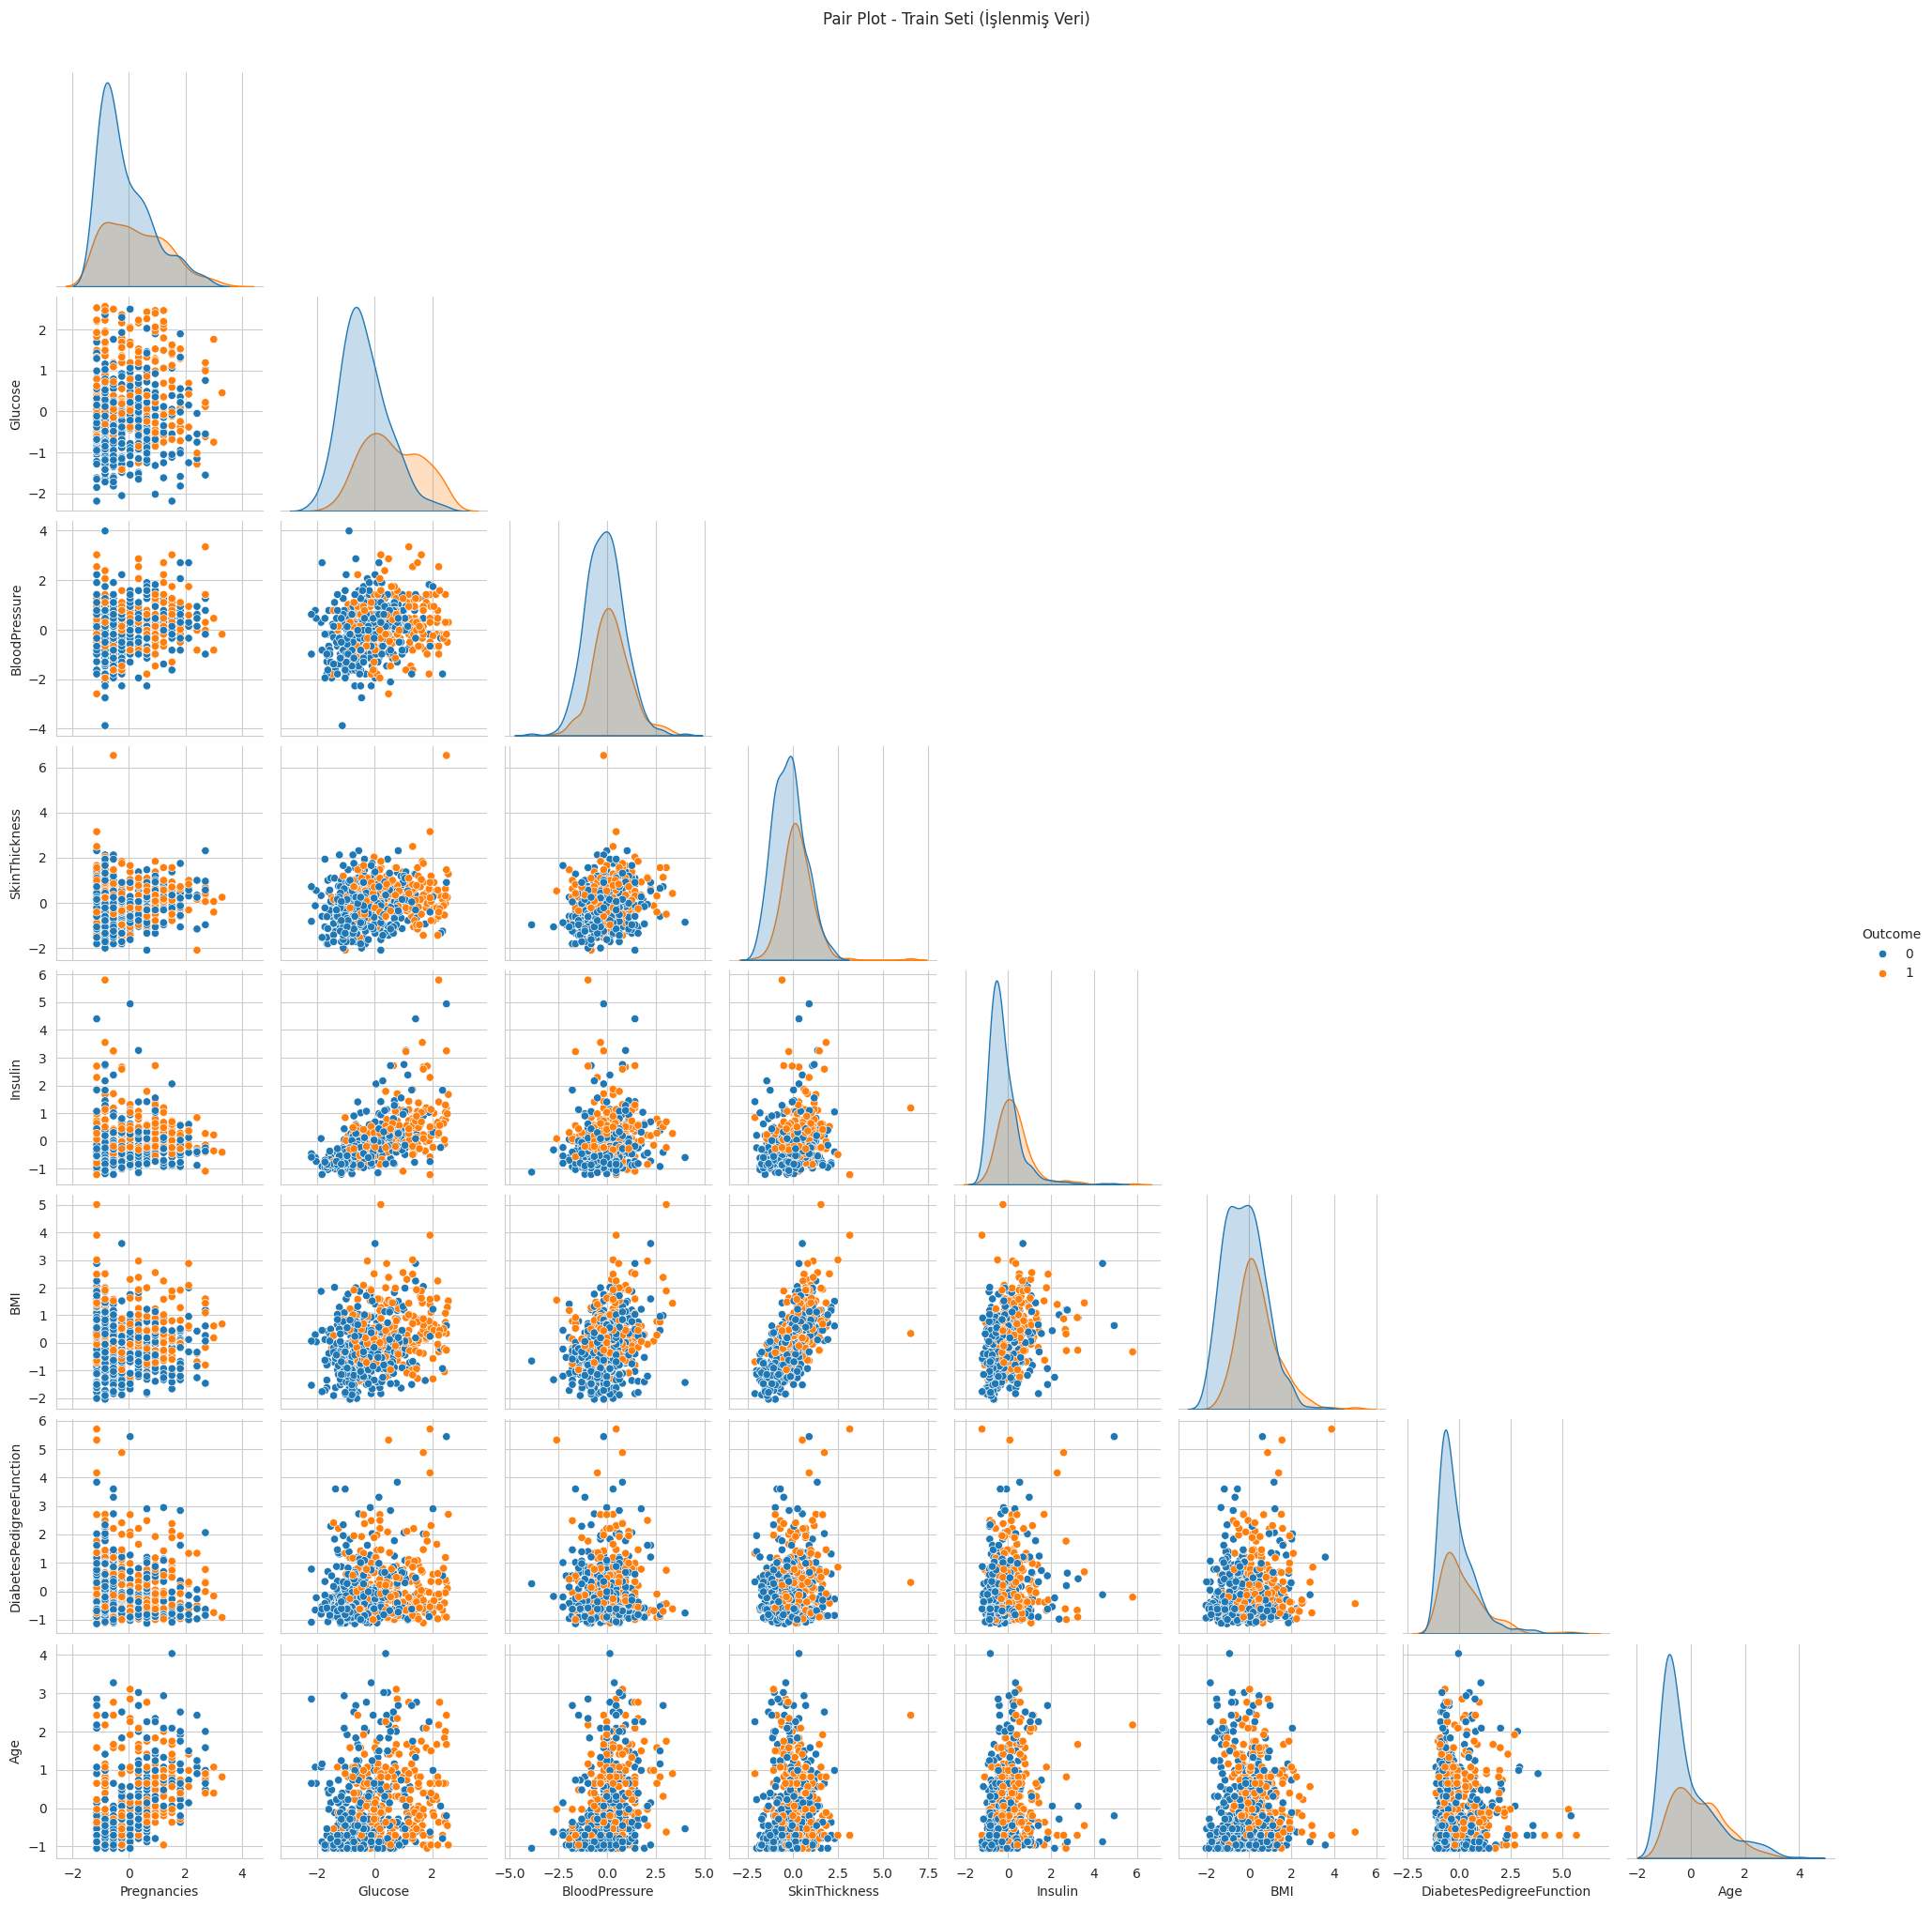


7. Eksik Değer Kontrolü:
Train Seti - Eksik Değer: 0
Test Seti - Eksik Değer: 0

8. Train Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    float64
 1   Glucose                   614 non-null    float64
 2   BloodPressure             614 non-null    float64
 3   SkinThickness             614 non-null    float64
 4   Insulin                   614 non-null    float64
 5   BMI                       614 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    float64
 8   Outcome                   614 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 43.3 KB
None

9. Test Seti Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 9 columns):

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-1.144320,0.019724,1.260018,0.716916,-0.339444,0.410501,-0.794223,-0.368382,0
1,2.112627,-0.648707,-0.344561,0.997737,0.601533,1.995766,-1.001824,0.732901,0
2,0.632197,-1.016344,-0.825935,0.248880,-0.268617,-0.050667,-1.121705,1.071757,0
3,-0.848233,1.390008,0.778645,1.278559,-0.766087,0.064625,-0.373175,1.410613,0
4,1.224369,0.353940,-0.023645,0.211437,0.289561,0.079037,-0.580775,0.478758,1



11. İlk 5 Satır - Test Seti:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.256061,-0.748972,-0.344561,-0.593585,-0.648044,-0.108313,1.404585,-0.453096,0
1,-0.256061,1.623959,-0.023645,0.342487,-0.192732,0.136683,-0.788375,-0.791952,1
2,-0.848233,0.721577,0.778645,0.997737,0.913506,1.289603,0.404595,-0.453096,0
3,-0.256061,-0.548442,-0.023645,-0.911849,-0.720556,-0.944179,-0.764984,-0.537810,0
4,-0.552147,0.788420,-0.135966,-0.069385,0.083827,-0.699184,-0.668494,-0.453096,1



✅ Ön işleme sonrası veri setleri incelendi!

📝 Notlar:
- Tüm veriler StandardScaler ile normalize edildi (ortalama≈0, std≈1)
- Eksik değerler KNNImputer ile dolduruldu
- Train ve Test setleri ayrı ayrı işlendi (data leakage önlendi)
- Veri setleri model eğitimi için hazır!


In [4]:
# --- 4. Ön İşleme Sonrası Veri Setlerini İnceleme (EDA) ---

# Train ve Test setlerini birleştirip yeni DataFrame'ler oluşturalım (EDA için)
train_df = X_train_df.copy()
train_df['Outcome'] = y_train.values

test_df = X_test_df.copy()
test_df['Outcome'] = y_test.values

print("=" * 80)
print("📊 İŞLENMİŞ EĞİTİM SETİ İNCELEMESİ")
print("=" * 80)

# 1. İstatistiksel Özet - Train Seti
print("\n1. İstatistiksel Özet (Train Seti):")
display(train_df.describe().T)

# 2. Hedef Değişken Dağılımı - Train Seti
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Outcome', data=train_df)
plt.title("Hedef Değişken Dağılımı - Train Seti\n(0: Sağlıklı, 1: Diyabet)")
plt.xlabel("Outcome")
plt.ylabel("Kişi Sayısı")

plt.subplot(1, 2, 2)
sns.countplot(x='Outcome', data=test_df)
plt.title("Hedef Değişken Dağılımı - Test Seti\n(0: Sağlıklı, 1: Diyabet)")
plt.xlabel("Outcome")
plt.ylabel("Kişi Sayısı")

plt.tight_layout()
plt.show()

# 3. Histogramlar - Train Seti (Özellikler)
print("\n2. Özelliklerin Histogram Dağılımı (Train Seti):")
train_df.drop('Outcome', axis=1).hist(figsize=(14, 10), bins=20, grid=False)
plt.suptitle("İşlenmiş Özelliklerin Histogram Dağılımı - Train Seti", fontsize=16)
plt.show()

# 4. Histogramlar - Test Seti (Özellikler)
print("\n3. Özelliklerin Histogram Dağılımı (Test Seti):")
test_df.drop('Outcome', axis=1).hist(figsize=(14, 10), bins=20, grid=False)
plt.suptitle("İşlenmiş Özelliklerin Histogram Dağılımı - Test Seti", fontsize=16)
plt.show()

# 5. Korelasyon Matrisi - Train Seti
print("\n4. Korelasyon Matrisi (Train Seti):")
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Korelasyon Matrisi - Train Seti (İşlenmiş Veri)")
plt.tight_layout()
plt.show()

# 6. Korelasyon Matrisi - Test Seti
print("\n5. Korelasyon Matrisi (Test Seti):")
plt.figure(figsize=(10, 8))
sns.heatmap(test_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Korelasyon Matrisi - Test Seti (İşlenmiş Veri)")
plt.tight_layout()
plt.show()

# 7. Pair Plot - Train Seti (Outcome'a göre)
print("\n6. Pair Plot - Değişken İlişkileri (Train Seti):")
sns.pairplot(train_df, hue='Outcome', diag_kind='kde', corner=True)
plt.suptitle("Pair Plot - Train Seti (İşlenmiş Veri)", y=1.02)
plt.show()

# 8. Eksik Değer Kontrolü
print("\n7. Eksik Değer Kontrolü:")
print(f"Train Seti - Eksik Değer: {train_df.isnull().sum().sum()}")
print(f"Test Seti - Eksik Değer: {test_df.isnull().sum().sum()}")

# 9. Veri Tipleri ve Genel Bilgi
print("\n8. Train Seti Bilgileri:")
print(train_df.info())

print("\n9. Test Seti Bilgileri:")
print(test_df.info())

# 10. İlk 5 satır - Train Seti
print("\n10. İlk 5 Satır - Train Seti:")
display(train_df.head())

# 11. İlk 5 satır - Test Seti
print("\n11. İlk 5 Satır - Test Seti:")
display(test_df.head())

print("\n" + "=" * 80)
print("✅ Ön işleme sonrası veri setleri incelendi!")
print("=" * 80)
print("\n📝 Notlar:")
print("- Tüm veriler StandardScaler ile normalize edildi (ortalama≈0, std≈1)")
print("- Eksik değerler KNNImputer ile dolduruldu")
print("- Train ve Test setleri ayrı ayrı işlendi (data leakage önlendi)")
print("- Veri setleri model eğitimi için hazır!")
